# AUC Calculations from Raw Growth Curve Data

Required inputs (place both files in the directory named below):

'Data.xlsx' - this has the raw OD readings exported from the plate reader (wells as rows, timepoints as columns)

'Plan.xlsx' — this is the plate layout that maps the well position to strain name/condition

## Imports

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

## Configuration

Remember to set the experiment directory name below with your data.xlsx and plan.xlsx files within it.

In [70]:
#Name of the experimental subdirectory
EXPERIMENT_DIR = "Sorbitol"

#Cut-off time (hours): timepoints beyond this are excluded from both the curve plot and AUC calculation.
#A good rule of thumb is to use the plateau onset time + ~2 hours
#Inspect the curve plot in the next section to confirm your choice.
T_END = 18

#Derive the paths and output names automatically
experiment_path = Path(EXPERIMENT_DIR)
data_path   = experiment_path / "Data.xlsx"
plan_path   = experiment_path / "Plan.xlsx"

out_prefix = experiment_path / EXPERIMENT_DIR
out_curves   = Path(str(out_prefix) + "_curves.png")
out_excel    = Path(str(out_prefix) + "_AUC_calculations.xlsx")
out_boxplot  = Path(str(out_prefix) + "_AUC_boxplot.png")

## Load and Orient Data

The plate reader exports a table with wells as rows and timepoints as columns.
We transpose it so that rows = timepoints and columns = well names, which
is the orientation expected by the rest of the notebook.

In [73]:
#Import the data from your Excel sheet and turn it into a dataframe called source_df
source_df = pd.read_excel(data_path, header=0, index_col=0)

#Now we are going to transpose the data frame so that time is along the rows and well numbers are columns. This is done by the .T
#Make sure the preview shows the correct orientation: rows = timepoints, columns = wells.
source_df = source_df.T
source_df.index = source_df.index.astype(float)  #Ensure timepoints are numeric
source_df.head()

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,...,H3,H4,H5,H6,H7,H8,H9,H10,H11,H12
0.000000,0.1448,0.1443,0.1426,0.1393,0.1371,0.1395,0.1422,0.1386,0.1367,0.1402,...,0.1460,0.1498,0.1494,0.1416,0.1337,0.1319,0.1390,0.1333,0.1165,0.1162
0.333333,0.1131,0.1132,0.1135,0.1140,0.1138,0.1171,0.1200,0.1143,0.1139,0.1143,...,0.1172,0.1183,0.1182,0.1180,0.1177,0.1174,0.1181,0.1165,0.1170,0.1167
0.666667,0.1131,0.1131,0.1135,0.1140,0.1140,0.1174,0.1200,0.1142,0.1152,0.1142,...,0.1168,0.1181,0.1183,0.1177,0.1173,0.1171,0.1177,0.1164,0.1166,0.1164
1.000000,0.1130,0.1130,0.1134,0.1139,0.1138,0.1181,0.1198,0.1141,0.1139,0.1140,...,0.1165,0.1178,0.1177,0.1174,0.1171,0.1169,0.1176,0.1161,0.1165,0.1161
1.333333,0.1130,0.1129,0.1133,0.1138,0.1136,0.1180,0.1197,0.1140,0.1139,0.1138,...,0.1157,0.1174,0.1173,0.1168,0.1165,0.1163,0.1169,0.1154,0.1158,0.1155


## Choose a Cut-Off Time

Plot a representative subset of wells to inspect curve shapes and confirm your T_END.
The dashed lines mark T_END - 2 and T_END. The plateau should begin no later than T_END - 2.

Adjust T_END in the Configuration cell above if needed, then re-run from there.

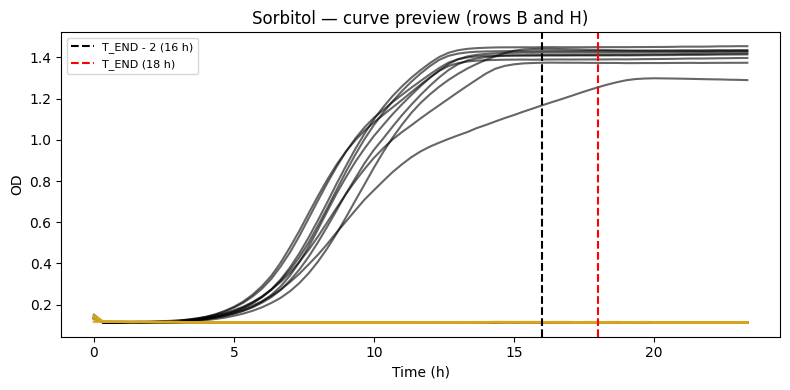

In [76]:
#Pick just a couple of wells to plot so the graph won't be too confusing (here we use rows B and H)
fig, ax = plt.subplots(figsize=(8, 4))

for col in source_df.columns:
    if col.startswith('B'):
        ax.plot(source_df[col], color='black', alpha=0.6)
    elif col.startswith('H'):
        ax.plot(source_df[col], color='goldenrod', alpha=0.6)

#Dashed lines showing the cut-off window (plateau onset and T_END)
ax.axvline(T_END - 2, color='black', linestyle='--', label=f'T_END - 2 ({T_END-2} h)')
ax.axvline(T_END,     color='red',   linestyle='--', label=f'T_END ({T_END} h)')

ax.set_xlabel("Time (h)")
ax.set_ylabel("OD")
ax.set_title(f"{EXPERIMENT_DIR} — curve preview (rows B and H)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Load the plate plan and build a long-form dataframe

The plate plan maps each well to its strain and condition.
We reshape everything into a long-form dataframe where each row represents one
(well, timepoint) combination, making downstream grouping and plotting simple.

In [79]:
#Import the spreadsheet that shows your plate setup and turn it into a dataframe
plate_df = pd.read_excel(plan_path, header=0, index_col=0)
print(plate_df)

#Build a lookup dictionary
dict_of_dicts = {
    well: dict(row)
    for well, row in plate_df.iterrows()
}

     strain    medium
well                 
A1    Blank       YPD
A2    Blank       YPD
A3    Blank       YPD
A4    Blank       YPD
A5    Blank       YPD
...     ...       ...
H8    Blank  YPD_SORB
H9    Blank  YPD_SORB
H10   Blank  YPD_SORB
H11   Blank  YPD_SORB
H12   Blank  YPD_SORB

[96 rows x 2 columns]


In [81]:
#This function is going to create a long-form data frame that generates the OD at a specific time for a specific well
timepoint_list = list(source_df.index)
records = []

for well, row in plate_df.iterrows():
    for time in timepoint_list:
        record = {"time": time, "well": well}
        record.update(dict_of_dicts[well])
        record["OD"] = float(source_df.loc[time, well])
        records.append(record)

long_form_df = pd.DataFrame(records)
long_form_df.head()

,time,well,strain,medium,OD
0,0.000000,A1,Blank,YPD,0.1448
1,0.333333,A1,Blank,YPD,0.1131
2,0.666667,A1,Blank,YPD,0.1131
3,1.000000,A1,Blank,YPD,0.1130
4,1.333333,A1,Blank,YPD,0.1130


## Plot Per-Strain Growth Curves

The x-axis is capped at T_END.

Saved: Sorbitol/Sorbitol_curves.png


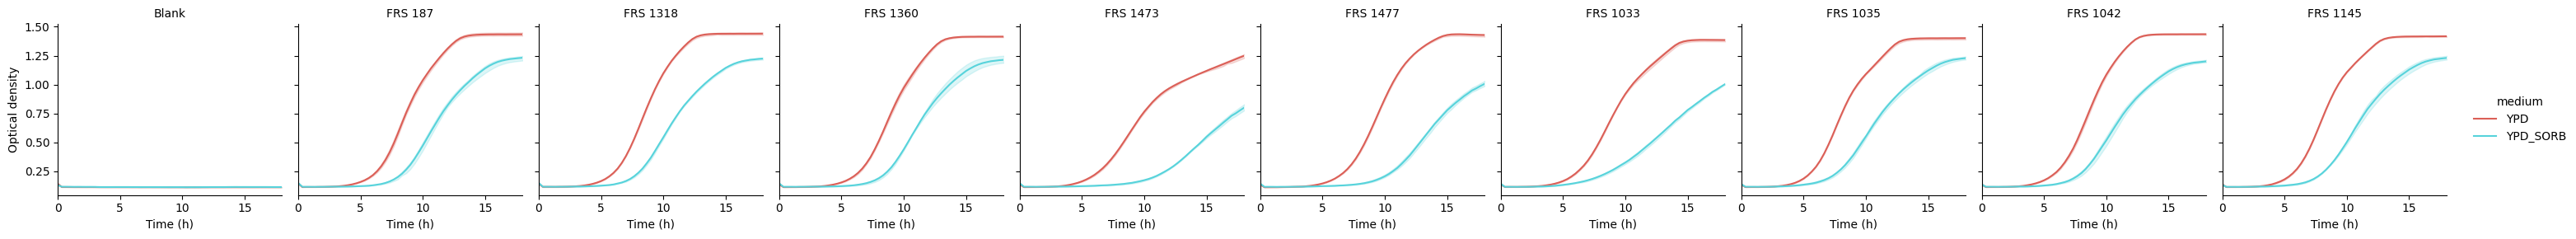

In [84]:
#Here we can create individual curves for each of the strains and save them as a .png.
#This code may take a few minutes to run.

grid = sns.FacetGrid(
    data=long_form_df,
    col='strain',
    hue='medium',
    palette='hls'
)  # you can change col and hue

grid.map(sns.lineplot, 'time', 'OD')
grid.set_titles(col_template='{col_name}', row_template='{row_name}')
grid.set_axis_labels('Time (h)', 'OD')
grid.add_legend()
grid.set(xlabel="Time (h)", ylabel="Optical density", xlim=(0, T_END))

plt.savefig(out_curves, format='png', dpi=300)
print(f"Saved: {out_curves}")
plt.show()

## Calculate AUC

We use the trapezoidal rule (np.trapezoid) to calculate the area under each well's growth curve
up to T_END. Passing the actual timepoint values (x=x_vals) is important, as otherwise Numpy assumes evenly-spaced unit intervals (ie. 1h), which would be wrong for 20-minute intervals.

In [87]:
#Calculate the area under the curve
def get_auc(well, df, t_end=T_END):
    #Set the cutoff time to be T_END hours for calculating the AUC
    df_trimmed = df.loc[df.index <= t_end]
    y_vals = df_trimmed[well].tolist()
    x_vals = list(df_trimmed.index)

    #Set the x=x_vals to take the actual x value instead of assuming that they are equal to one.
    #This is important when you are setting the interval time to either 20 mins or 15 mins
    return np.trapezoid(y_vals, x=x_vals)

In [89]:
#Verify the AUC calculation on a single well (usually a blank or CTRL well is a good sanity check)
test_well = 'A1'
print(f"AUC for {test_well}: {get_auc(test_well, source_df):.4f}")

AUC for A1: 1.9927


## Assign AUC Values

We compute the AUC for every well and attach it to the long-form dataframe.
Because each well has one AUC but many timepoints, every row for a given well
receives the same AUC value (we collapse to one row per well in the next step).

In [92]:
#This will now list all of the AUC values for each well
wells_in_order = long_form_df['well'].tolist()
list_auc = [get_auc(well, source_df, t_end=T_END) for well in wells_in_order]

#Print the list of AUC so now you can see it in the long-form data spreadsheet.
#It will assign the same AUC value to the corresponding well across all time points for that well
long_form_df['auc'] = np.array(list_auc)
long_form_df.head()

,time,well,strain,medium,OD,auc
0,0.000000,A1,Blank,YPD,0.1448,1.99275
1,0.333333,A1,Blank,YPD,0.1131,1.99275
2,0.666667,A1,Blank,YPD,0.1131,1.99275
3,1.000000,A1,Blank,YPD,0.1130,1.99275
4,1.333333,A1,Blank,YPD,0.1130,1.99275


## Collapse to One Row per Well and Save

We keep only the time == 0 rows so that each well appears exactly once in the output,
along with its AUC value and all the other metadata from the plate plan file.

In [95]:
# This cell drops all of the other time points except for 0 because we only need 1 AUC value for each of the wells

auc_df = long_form_df[long_form_df['time'] == 0.0].copy()
auc_df = auc_df.drop(columns='time')  # time == 0 is no longer informative
auc_df = auc_df.reset_index(drop=True)

# This is the file that is the output with the AUC data
auc_df.to_excel(out_excel, index=False)
print(f"Saved: {out_excel}")

# Here we are printing out the new dataframe where there is only 96 rows,
# each representing a well with the corresponding final AUC
auc_df

Saved: Sorbitol/Sorbitol_AUC_calculations.xlsx


,well,strain,medium,OD,auc
0,A1,Blank,YPD,0.1448,1.992750
1,A2,Blank,YPD,0.1443,1.990383
2,A3,Blank,YPD,0.1426,1.997350
3,A4,Blank,YPD,0.1393,2.005817
4,A5,Blank,YPD,0.1371,2.003217
...,...,...,...,...,...
91,H8,Blank,YPD_SORB,0.1319,2.030800
92,H9,Blank,YPD_SORB,0.1390,2.042700
93,H10,Blank,YPD_SORB,0.1333,2.015300
94,H11,Blank,YPD_SORB,0.1165,2.019767


## Boxplot of AUC Values

Saved: Sorbitol/Sorbitol_AUC_boxplot.png


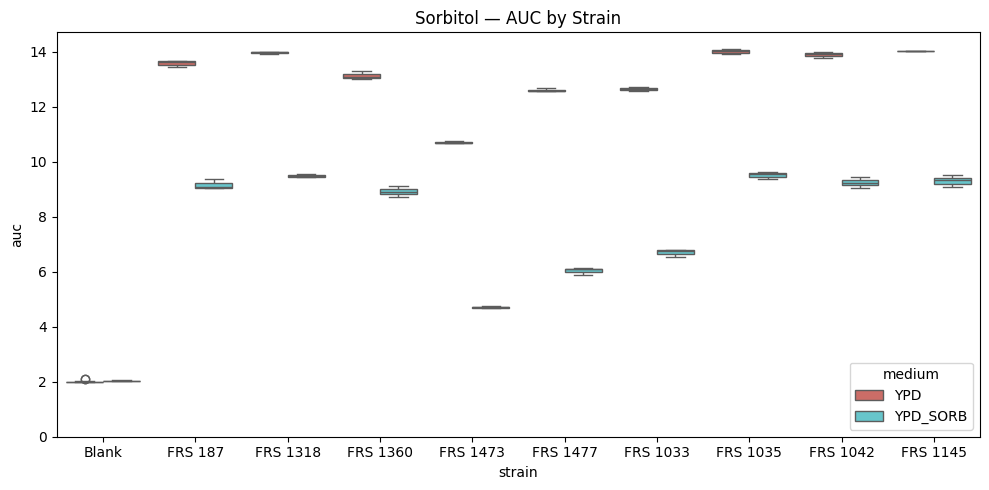

In [98]:
#Now we can graph the AUC data as a box plot

fig, ax = plt.subplots(figsize=(10, 5))

#Be sure to change the hue variable if your Plan.xlsx uses a different column name for the condition
sns.boxplot(
    x='strain', y='auc', hue='medium',
    data=auc_df,
    palette='hls',
    ax=ax
)

ax.set_ylim(0, None)  # auto upper limit; set a fixed value (e.g. 15) if you prefer
ax.set_title(f"{EXPERIMENT_DIR} — AUC by Strain")
plt.tight_layout()

plt.savefig(out_boxplot, format='png', dpi=300)
print(f"Saved: {out_boxplot}")
plt.show()